## Cell 1: Install required libraries

In [1]:
!pip install tiktoken -q
!pip install torch -q

## Cell 2: Imports and device setup

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken
import math
import time
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

torch.manual_seed(1337)

Using device: cuda


## Cell 3: Upload the dataset file
Upload `tips-ML-Phenotype.txt` to your Colab session.
Run this cell and click 'Choose Files' to upload.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving tips_ML_Phenotype.txt to tips_ML_Phenotype (2).txt


## Cell 4: Load text data

In [4]:
with open('tips_ML_Phenotype.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Total characters in dataset: {len(text)}")
print(f"\nFirst 500 characters:\n{text[:500]}")

Total characters in dataset: 36358

First 500 characters:
Phenotyping Data and ML
The enormous volume, variety, velocity, and veracity of imaging and remote-sensing data
generated by such real-time platforms represent a ‘big data’ problem. The data generated
by these near real-time platforms must be efﬁciently archived and retrieved for analysis. Although
the analysis and interpretation of such (image-based) big data are challenging, the ensuing
possibilities that can impact on agricultural production make it a promising approach for HTP
and HTSP. ML a


## Cell 5: Modification (a) - Sub-word tokenization with tiktoken
Replaces simple character-level (stoi/itos) mapping with GPT-2's BPE tokenizer.

In [5]:
enc = tiktoken.get_encoding('gpt2')
vocab_size = enc.n_vocab
print(f"Vocabulary size (sub-word): {vocab_size}")

data = torch.tensor(enc.encode(text), dtype=torch.long)
print(f"Total tokens after sub-word encoding: {len(data)}")

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Vocabulary size (sub-word): 50257
Total tokens after sub-word encoding: 8623
Train tokens: 7760
Val tokens: 863


## Cell 6: Hyperparameters and batch loader

In [6]:
block_size = 128
batch_size = 32
max_iters = 2000
eval_interval = 200
eval_iters = 50
learning_rate = 3e-4
n_head = 4
dropout = 0.2

def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

## Cell 7: Modification (b) - Rotary Positional Embeddings (RoPE)
Replaces fixed `nn.Embedding(block_size, n_embd)` with rotary embeddings applied directly to query/key vectors.

In [7]:
def precompute_rope_freqs(head_dim, max_seq_len, base=10000.0):
    freqs = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    t = torch.arange(max_seq_len).float()
    freqs = torch.outer(t, freqs)
    cos = freqs.cos()
    sin = freqs.sin()
    return cos, sin

def apply_rope(x, cos, sin):
    B, H, T, D = x.shape
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    cos = cos[:T, :].unsqueeze(0).unsqueeze(0)
    sin = sin[:T, :].unsqueeze(0).unsqueeze(0)
    rotated_x1 = x1 * cos - x2 * sin
    rotated_x2 = x1 * sin + x2 * cos
    out = torch.stack([rotated_x1, rotated_x2], dim=-1).flatten(-2)
    return out

## Cell 8: Multi-head Self-Attention with RoPE

In [8]:
class MultiHeadAttentionRoPE(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.n_embd = n_embd

        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

        cos, sin = precompute_rope_freqs(self.head_dim, block_size)
        self.register_buffer('rope_cos', cos)
        self.register_buffer('rope_sin', sin)

        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.qkv(x)
        q, k, v = qkv.split(self.n_embd, dim=-1)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        q = apply_rope(q, self.rope_cos, self.rope_sin)
        k = apply_rope(k, self.rope_cos, self.rope_sin)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        out = self.proj(out)
        return out

## Cell 9: Feed-forward and Transformer Block

In [9]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MultiHeadAttentionRoPE(n_embd, n_head, block_size)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff = FeedForward(n_embd)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

## Cell 10: Full GPT model with RoPE (no positional embedding table)

In [10]:
class GPTModelRoPE(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size):
        super().__init__()
        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, n_embd)

        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size) for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        x = self.token_embedding(idx)

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat = targets.view(B*T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

## Cell 11: Training function

In [11]:
def train_model(n_layer, n_embd, max_iters=max_iters, verbose=True):
    model = GPTModelRoPE(
        vocab_size=vocab_size,
        n_embd=n_embd,
        n_head=n_head,
        n_layer=n_layer,
        block_size=block_size
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    if verbose:
        print(f"\n{'='*60}")
        print(f"Training: n_layer={n_layer}, n_embd={n_embd}")
        print(f"Total parameters: {n_params:,}")
        print(f"{'='*60}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    iters_log = []

    start_time = time.time()

    for iter_num in range(max_iters):
        if iter_num % eval_interval == 0 or iter_num == max_iters - 1:
            losses = estimate_loss(model)
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            iters_log.append(iter_num)
            if verbose:
                print(f"Step {iter_num:4d} | train loss: {losses['train']:.4f} | val loss: {losses['val']:.4f}")

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    elapsed = time.time() - start_time

    final_losses = estimate_loss(model)

    if verbose:
        print(f"\nFinal train loss: {final_losses['train']:.4f}")
        print(f"Final val loss: {final_losses['val']:.4f}")
        print(f"Training time: {elapsed:.1f}s")

    return {
        'model': model,
        'final_train_loss': final_losses['train'],
        'final_val_loss': final_losses['val'],
        'train_losses': train_losses,
        'val_losses': val_losses,
        'iters': iters_log,
        'n_params': n_params,
        'time': elapsed
    }

## Cell 12: Quick baseline run (n_layer=4, n_embd=128) to verify pipeline

In [12]:
baseline = train_model(n_layer=4, n_embd=128)

context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_ids = baseline['model'].generate(context, max_new_tokens=200)[0].tolist()
generated_text = enc.decode(generated_ids)
print("\n" + "="*60)
print("Sample generated text from baseline model:")
print("="*60)
print(generated_text)


Training: n_layer=4, n_embd=128
Total parameters: 13,707,857
Step    0 | train loss: 10.8526 | val loss: 10.8572
Step  200 | train loss: 4.2200 | val loss: 6.3251
Step  400 | train loss: 1.5276 | val loss: 6.5013
Step  600 | train loss: 0.5409 | val loss: 7.2109
Step  800 | train loss: 0.2070 | val loss: 7.7019
Step 1000 | train loss: 0.1040 | val loss: 8.0503
Step 1200 | train loss: 0.0737 | val loss: 8.3262
Step 1400 | train loss: 0.0599 | val loss: 8.4577
Step 1600 | train loss: 0.0528 | val loss: 8.7490
Step 1800 | train loss: 0.0471 | val loss: 8.8401
Step 1999 | train loss: 0.0444 | val loss: 8.8920

Final train loss: 0.0447
Final val loss: 8.9350
Training time: 275.9s

Sample generated text from baseline model:
!
, dirt, and the practitioner should (carefully) down-select from the foreground from choices based on the
type plant stress similar patterns synthetically. In the context of the previous example, the advantages of using unsupervised nature of the target classii) Our re

## Cell 13: Modification (c) - Hyperparameter search
Grid search over n_layer ∈ {4, 6, 8} and n_embd ∈ {64, 128, 256} = 9 configurations.

In [13]:
n_layer_values = [4, 6, 8]
n_embd_values = [64, 128, 256]

results = {}

for n_layer in n_layer_values:
    for n_embd in n_embd_values:
        key = f"L{n_layer}_E{n_embd}"
        result = train_model(n_layer=n_layer, n_embd=n_embd, verbose=True)
        results[key] = {
            'n_layer': n_layer,
            'n_embd': n_embd,
            'final_train_loss': result['final_train_loss'],
            'final_val_loss': result['final_val_loss'],
            'n_params': result['n_params'],
            'time': result['time']
        }
        del result
        torch.cuda.empty_cache()

print("\n\n" + "="*60)
print("All configurations completed!")
print("="*60)


Training: n_layer=4, n_embd=64
Total parameters: 6,682,449
Step    0 | train loss: 10.8259 | val loss: 10.8366
Step  200 | train loss: 6.1065 | val loss: 7.1426
Step  400 | train loss: 4.3107 | val loss: 6.4388
Step  600 | train loss: 2.5665 | val loss: 6.2896
Step  800 | train loss: 1.4137 | val loss: 6.7113
Step 1000 | train loss: 0.8253 | val loss: 7.1115
Step 1200 | train loss: 0.4948 | val loss: 7.4627
Step 1400 | train loss: 0.2969 | val loss: 7.8229
Step 1600 | train loss: 0.1881 | val loss: 7.9941
Step 1800 | train loss: 0.1318 | val loss: 8.2428
Step 1999 | train loss: 0.1012 | val loss: 8.4011

Final train loss: 0.1028
Final val loss: 8.4067
Training time: 204.8s

Training: n_layer=4, n_embd=128
Total parameters: 13,707,857
Step    0 | train loss: 10.8405 | val loss: 10.8387
Step  200 | train loss: 4.2255 | val loss: 6.4054
Step  400 | train loss: 1.5796 | val loss: 6.5733
Step  600 | train loss: 0.5498 | val loss: 7.2347
Step  800 | train loss: 0.1998 | val loss: 7.7118
Ste

## Cell 14: Display results table

In [14]:
print(f"{'Config':<12} {'n_layer':<10} {'n_embd':<10} {'Params':<15} {'Train Loss':<12} {'Val Loss':<12} {'Time (s)':<10}")
print("-" * 90)
for key, r in results.items():
    print(f"{key:<12} {r['n_layer']:<10} {r['n_embd']:<10} {r['n_params']:<15,} {r['final_train_loss']:<12.4f} {r['final_val_loss']:<12.4f} {r['time']:<10.1f}")

best_config = min(results.items(), key=lambda x: x[1]['final_val_loss'])
print(f"\nBest configuration (lowest val loss): {best_config[0]}")
print(f"  n_layer = {best_config[1]['n_layer']}")
print(f"  n_embd  = {best_config[1]['n_embd']}")
print(f"  val_loss = {best_config[1]['final_val_loss']:.4f}")

Config       n_layer    n_embd     Params          Train Loss   Val Loss     Time (s)  
------------------------------------------------------------------------------------------
L4_E64       4          64         6,682,449       0.1028       8.4067       204.8     
L4_E128      4          128        13,707,857      0.0430       8.9451       275.2     
L4_E256      4          256        28,938,321      0.0343       8.8979       456.2     
L6_E64       6          64         6,782,033       0.0983       8.5119       214.8     
L6_E128      6          128        14,103,633      0.0437       9.0906       294.5     
L6_E256      6          256        30,516,305      0.0350       8.8998       508.1     
L8_E64       8          64         6,881,617       0.1137       8.5314       226.1     
L8_E128      8          128        14,499,409      0.0441       8.9068       318.8     
L8_E256      8          256        32,094,289      0.0337       8.9014       562.8     

Best configuration (lowest v

## Cell 15: Visualize hyperparameter search results as heatmap

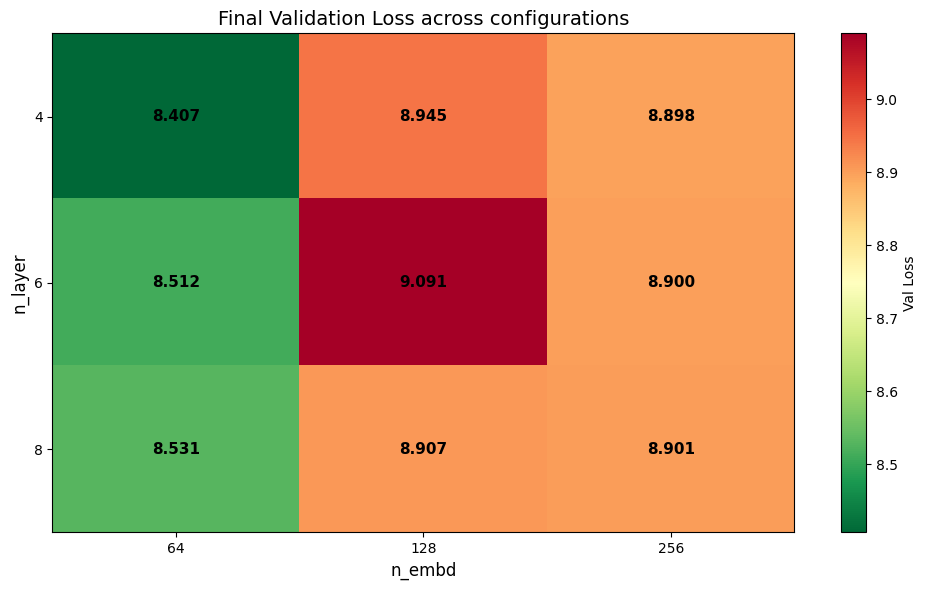

In [15]:
loss_matrix = np.zeros((len(n_layer_values), len(n_embd_values)))

for i, nl in enumerate(n_layer_values):
    for j, ne in enumerate(n_embd_values):
        key = f"L{nl}_E{ne}"
        loss_matrix[i, j] = results[key]['final_val_loss']

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(loss_matrix, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(n_embd_values)))
ax.set_yticks(range(len(n_layer_values)))
ax.set_xticklabels(n_embd_values)
ax.set_yticklabels(n_layer_values)
ax.set_xlabel('n_embd', fontsize=12)
ax.set_ylabel('n_layer', fontsize=12)
ax.set_title('Final Validation Loss across configurations', fontsize=14)

for i in range(len(n_layer_values)):
    for j in range(len(n_embd_values)):
        ax.text(j, i, f"{loss_matrix[i, j]:.3f}", ha='center', va='center',
                color='black', fontsize=11, fontweight='bold')

plt.colorbar(im, label='Val Loss')
plt.tight_layout()
plt.savefig('hyperparam_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16: Bar chart comparison of all configurations

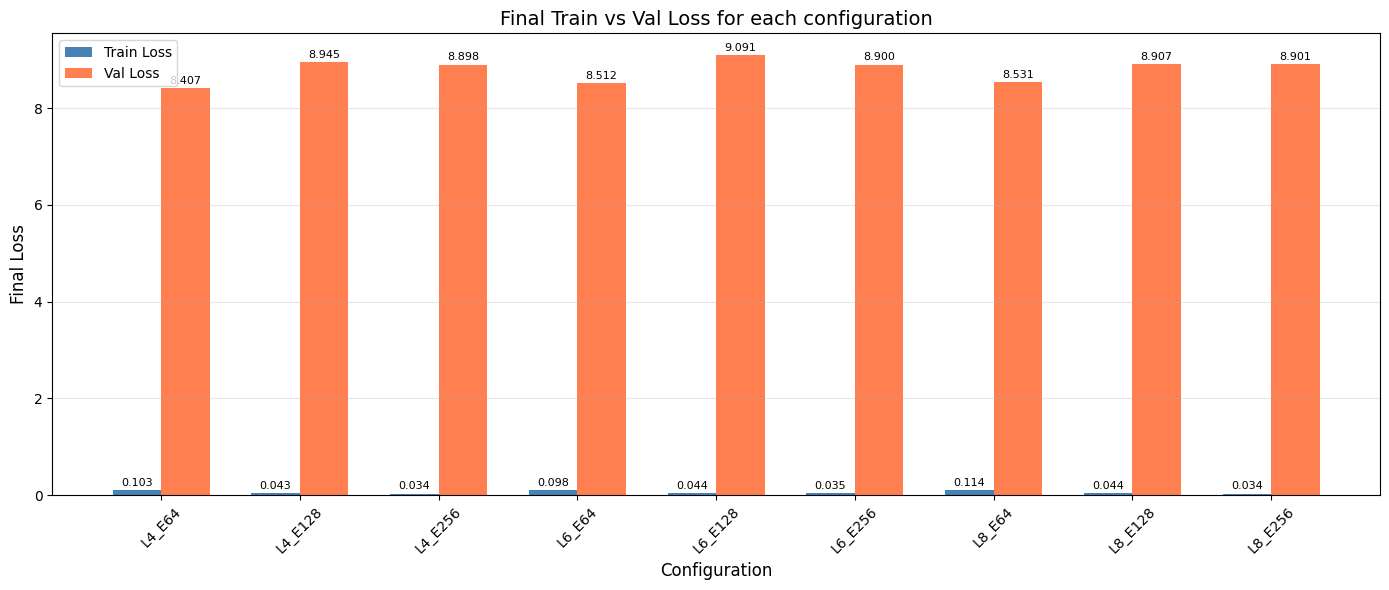

In [16]:
configs = list(results.keys())
train_losses_final = [results[k]['final_train_loss'] for k in configs]
val_losses_final = [results[k]['final_val_loss'] for k in configs]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_losses_final, width, label='Train Loss', color='steelblue')
bars2 = ax.bar(x + width/2, val_losses_final, width, label='Val Loss', color='coral')

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('Final Loss', fontsize=12)
ax.set_title('Final Train vs Val Loss for each configuration', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('config_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 17: Train the best configuration for longer and generate text

In [17]:
best_n_layer = best_config[1]['n_layer']
best_n_embd = best_config[1]['n_embd']

print(f"Training best config (n_layer={best_n_layer}, n_embd={best_n_embd}) for longer...")
best_run = train_model(n_layer=best_n_layer, n_embd=best_n_embd, max_iters=3000)

context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_ids = best_run['model'].generate(context, max_new_tokens=300)[0].tolist()
generated_text = enc.decode(generated_ids)
print("\n" + "="*60)
print("Generated text from BEST model:")
print("="*60)
print(generated_text)

Training best config (n_layer=4, n_embd=64) for longer...

Training: n_layer=4, n_embd=64
Total parameters: 6,682,449
Step    0 | train loss: 10.8390 | val loss: 10.8435
Step  200 | train loss: 6.1136 | val loss: 7.1551
Step  400 | train loss: 4.3171 | val loss: 6.4130
Step  600 | train loss: 2.5873 | val loss: 6.2300
Step  800 | train loss: 1.3982 | val loss: 6.6135
Step 1000 | train loss: 0.8135 | val loss: 7.0166
Step 1200 | train loss: 0.4802 | val loss: 7.3847
Step 1400 | train loss: 0.2849 | val loss: 7.7193
Step 1600 | train loss: 0.1783 | val loss: 7.9135
Step 1800 | train loss: 0.1257 | val loss: 8.1502
Step 2000 | train loss: 0.0965 | val loss: 8.2579
Step 2200 | train loss: 0.0817 | val loss: 8.4314
Step 2400 | train loss: 0.0713 | val loss: 8.5873
Step 2600 | train loss: 0.0622 | val loss: 8.7622
Step 2800 | train loss: 0.0586 | val loss: 8.9339
Step 2999 | train loss: 0.0541 | val loss: 9.0861

Final train loss: 0.0534
Final val loss: 8.9837
Training time: 305.7s

Generate